C. Customer/Seat Segmentation (Clustering)

* Objective: Identify distinct segments of seat categories based on aggregated transaction behavior.


* Approach: Data was aggregated by Seat_Category_Code, and K-Means clustering with 3 clusters was applied to the aggregated features (mean ticket price, mean days before match, etc.).


* Findings: The primary differentiator for the identified seat clusters was the mean ticket price. Other aggregated features showed similar mean values across the clusters, suggesting that while seat categories differentiate based on price, other aspects of purchasing behavior might be more influenced by factors beyond just the seat category. The clusters represent low, medium-high, and high average ticket price seat categories.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
from sklearn.cluster import KMeans

In [3]:
# Load the dataset
df = pd.read_csv('synthetic_sports_transactions.csv')
df.head(5)

,Event_ID,League_Code,Team_A_Code,Team_B_Code,Match_Date,Stadium_Code,City_Code,Seat_Category_Code,Ticket_Price,Sale_Date,Days_Before_Match,Quantity,Weather_Code,Day_of_Week_Code,Demand_Level_Code
0,436,7,64,70,2025-05-21,8,8,3,15000,2024-12-22,150,5,2,3,2
1,192,2,17,13,2024-04-19,10,10,4,11059,2024-04-04,15,3,4,5,2
2,485,3,28,30,2025-02-15,10,10,1,11935,2024-10-08,130,4,4,6,2
3,431,8,79,80,2024-12-03,2,2,2,15000,2024-10-20,44,2,2,2,3
4,462,8,74,78,2023-08-05,9,9,1,9060,2023-07-21,15,1,1,6,3


In [4]:
# Outlier handling for Ticket_Price (clipping)
lower_bound = df['Ticket_Price'].quantile(0.01)
upper_bound = df['Ticket_Price'].quantile(0.99)
df['Ticket_Price_clipped'] = df['Ticket_Price'].clip(lower=lower_bound, upper=upper_bound)

print(f"Original Ticket_Price range: {df['Ticket_Price'].min()} - {df['Ticket_Price'].max()}")
print(f"Clipped Ticket_Price range: {df['Ticket_Price_clipped'].min()} - {df['Ticket_Price_clipped'].max()}")


Original Ticket_Price range: 229 - 15000
Clipped Ticket_Price range: 723.9300000000001 - 15000.0


In [5]:
# Aggregates per Event_ID
event_aggregates = df.groupby('Event_ID').agg(
    Total_Tickets_Sold=('Quantity', 'sum'),
    Average_Price=('Ticket_Price_clipped', 'mean'),
    Peak_Demand_Days=('Days_Before_Match', 'max')
).reset_index()
display(event_aggregates.head())



,Event_ID,Total_Tickets_Sold,Average_Price,Peak_Demand_Days
0,1,75,13429.500000,178
1,2,146,10469.702500,173
2,3,86,10773.866667,180
3,4,152,12646.250000,175
4,5,88,11478.495000,168


In [6]:
# Merge aggregates back to the original dataframe
df = pd.merge(df, event_aggregates, on='Event_ID', how='left')
display(df.head())

,Event_ID,League_Code,Team_A_Code,Team_B_Code,Match_Date,Stadium_Code,City_Code,Seat_Category_Code,Ticket_Price,Sale_Date,Days_Before_Match,Quantity,Weather_Code,Day_of_Week_Code,Demand_Level_Code,Ticket_Price_clipped,Total_Tickets_Sold,Average_Price,Peak_Demand_Days
0,436,7,64,70,2025-05-21,8,8,3,15000,2024-12-22,150,5,2,3,2,15000.0,109,13537.555556,180
1,192,2,17,13,2024-04-19,10,10,4,11059,2024-04-04,15,3,4,5,2,11059.0,166,13165.000000,143
2,485,3,28,30,2025-02-15,10,10,1,11935,2024-10-08,130,4,4,6,2,11935.0,89,11202.684211,169
3,431,8,79,80,2024-12-03,2,2,2,15000,2024-10-20,44,2,2,2,3,15000.0,115,12332.173913,173
4,462,8,74,78,2023-08-05,9,9,1,9060,2023-07-21,15,1,1,6,3,9060.0,150,13444.222222,179


In [8]:
# Group by Seat_Category_Code and calculate the mean of relevant features
df_seat_agg = df.groupby('Seat_Category_Code').agg(
    Mean_Ticket_Price=('Ticket_Price_clipped', 'mean'),
    Mean_Days_Before_Match=('Days_Before_Match', 'mean'),
    Mean_Quantity=('Quantity', 'mean'),
    Mean_Total_Tickets_Sold=('Total_Tickets_Sold', 'mean'),
    Mean_Average_Price=('Average_Price', 'mean'),
    Mean_Peak_Demand_Days=('Peak_Demand_Days', 'mean')
).reset_index()

# Display the aggregated DataFrame
display(df_seat_agg)

,Seat_Category_Code,Mean_Ticket_Price,Mean_Days_Before_Match,Mean_Quantity,Mean_Total_Tickets_Sold,Mean_Average_Price,Mean_Peak_Demand_Days
0,1,8730.180044,90.425140,5.524820,116.183347,11712.191183,171.245797
1,2,11939.356119,89.225667,5.567896,116.280612,11883.254864,171.049451
2,3,13049.811037,89.623794,5.504823,115.132235,11948.783425,171.323151
3,4,13834.388078,90.396594,5.483779,116.486618,11982.497920,171.231549


In [9]:
# Initialize KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit KMeans to the aggregated data and add cluster labels
df_seat_agg['Seat_Cluster'] = kmeans.fit_predict(df_seat_agg[['Mean_Ticket_Price', 'Mean_Days_Before_Match', 'Mean_Quantity', 'Mean_Total_Tickets_Sold', 'Mean_Average_Price', 'Mean_Peak_Demand_Days']])

# Display the DataFrame with cluster labels
display(df_seat_agg)

,Seat_Category_Code,Mean_Ticket_Price,Mean_Days_Before_Match,Mean_Quantity,Mean_Total_Tickets_Sold,Mean_Average_Price,Mean_Peak_Demand_Days,Seat_Cluster
0,1,8730.180044,90.425140,5.524820,116.183347,11712.191183,171.245797,1
1,2,11939.356119,89.225667,5.567896,116.280612,11883.254864,171.049451,0
2,3,13049.811037,89.623794,5.504823,115.132235,11948.783425,171.323151,2
3,4,13834.388078,90.396594,5.483779,116.486618,11982.497920,171.231549,2


In [10]:
# Group by 'Seat_Cluster' and calculate the mean of the features within each cluster
cluster_characteristics = df_seat_agg.groupby('Seat_Cluster')[['Mean_Ticket_Price', 'Mean_Days_Before_Match', 'Mean_Quantity', 'Mean_Total_Tickets_Sold', 'Mean_Average_Price', 'Mean_Peak_Demand_Days']].mean()

# Display the cluster characteristics
print("Characteristics of each Seat Cluster (Mean of Features):")
display(cluster_characteristics)

Characteristics of each Seat Cluster (Mean of Features):


,Mean_Ticket_Price,Mean_Days_Before_Match,Mean_Quantity,Mean_Total_Tickets_Sold,Mean_Average_Price,Mean_Peak_Demand_Days
Seat_Cluster,,,,,,
0,11939.356119,89.225667,5.567896,116.280612,11883.254864,171.049451
1,8730.180044,90.425140,5.524820,116.183347,11712.191183,171.245797
2,13442.099557,90.010194,5.494301,115.809426,11965.640672,171.277350


In [11]:
# Calculate and print the inertia
inertia = kmeans.inertia_
print(f"Inertia: {inertia}")

Inertia: 308350.1203272143


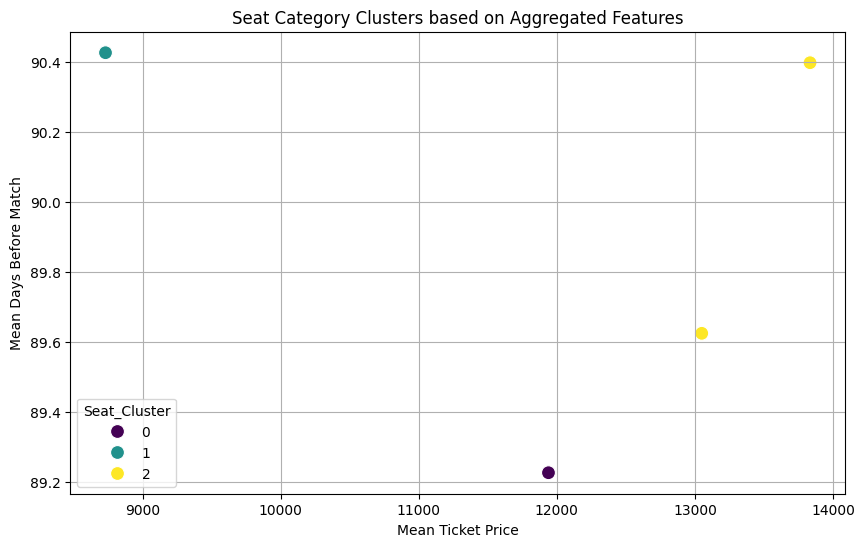

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_seat_agg, x='Mean_Ticket_Price', y='Mean_Days_Before_Match', hue='Seat_Cluster', palette='viridis', s=100)
plt.title('Seat Category Clusters based on Aggregated Features')
plt.xlabel('Mean Ticket Price')
plt.ylabel('Mean Days Before Match')
plt.grid(True)
plt.show()

## Summary:

### Data Analysis Key Findings

*   The transaction data was successfully aggregated by `Seat_Category_Code`, calculating the mean of features like ticket price, days before the match, quantity, total tickets sold, average price, and peak demand days for each category.
*   K-Means clustering with 3 clusters was applied to the aggregated data, assigning a cluster label to each seat category.
*   Analysis of the cluster characteristics revealed that the primary differentiator between the clusters was the mean ticket price:
    *   Cluster 1 had the lowest mean ticket price.
    *   Cluster 0 had a moderately high mean ticket price.
    *   Cluster 2 had the highest mean ticket price.
*   Other analyzed features (mean days before the match, mean quantity, mean total tickets sold, mean average price, and mean peak demand days) showed very similar average values across all three clusters.
